# K-Means Clustering

In [1]:
import numpy as np

import matplotlib.pyplot as plt

### Step 1: Load Data

In [2]:
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

#### Visualizing our loaded data

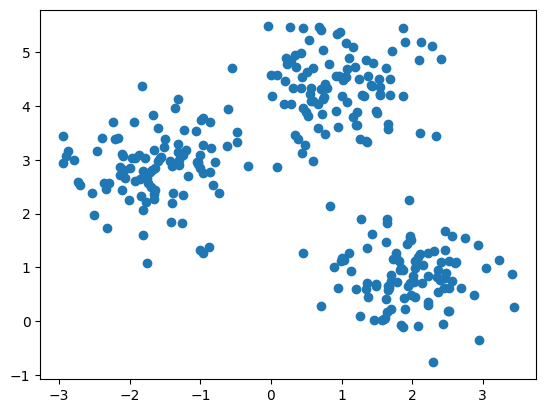

In [3]:
# Original points
plt.scatter(X[:, 0], X[:, 1])

### Step 2: Define our model

In [4]:
class KMeans:
    def __init__(self, k):
        self.k = k
        self.centroids = []
        self.labels = []

    def _squared_euclidean_distance(self, xi, uk):
        return np.sum(np.square(xi - uk))

    def fit(self, X, max_iters=100):
        self.X = X
        
        # Randomly initialize cluster centroids
        indices = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[indices]

        for iter in range(max_iters):
            old_centroids = np.array(self.centroids)
            
            # Assign points to cluster centroids
            labels = []
            
            for point in X:
                # Calculate distance between the point and each of the clusters [euclidean distance]
                best_distance = float('inf')
                closest_index = None
                
                for (index, centroid) in enumerate(self.centroids):
                    distance = self._squared_euclidean_distance(point, centroid)
    
                    if distance < best_distance:
                        best_distance = distance
                        closest_index = index
    
                labels.append(closest_index)
    
    
            labels = np.array(labels)
            self.labels = labels
    
            # Move cluster centroids
            # Find all labels for cluster 0, 1, 2...
            # For each, find the mean and set cluster in self.clusters to that
            for ind in range(len(self.centroids)): # 0, 1, 2, ...
                # Get all points belonging to this cluster
                cluster_points = X[labels == ind]
    
                if len(cluster_points) > 0:
                    self.centroids[ind] = np.mean(cluster_points, axis=0)
                else:
                    # Reinitialize centroid randomly
                    self.centroids[ind] = X[np.random.randint(0, len(X))]
    
            # Convergence check
            self.centroids = np.array(self.centroids)
            if np.allclose(old_centroids, self.centroids):
                # print(f"Converged at iteration {iter}")
                break

        return self.labels

    def compute_cost(self):
        total_cost = 0
        
        for i in range(len(self.X)):
            # Get the centroid assigned to the current point
            centroid = self.centroids[self.labels[i]]
            
            # Calculate squared Euclidean distance
            distance_sq = self._squared_euclidean_distance(self.X[i], centroid)
            total_cost += distance_sq
            
        return total_cost
        

### Step 3: Use Elbow method to pick the best number of clusters

In [5]:
# Plot cost function against number of clusters
costs = []

for k in range(1, 10):
    model = KMeans(k)
    model.fit(X)
    cost = model.compute_cost()

    costs.append(cost)

print(costs)

[np.float64(1517.0391167760838), np.float64(655.3392746547811), np.float64(212.4052203668122), np.float64(182.855714066637), np.float64(167.20530376251506), np.float64(163.45432777681322), np.float64(142.6281796771179), np.float64(104.17327553893765), np.float64(97.63717795375601)]


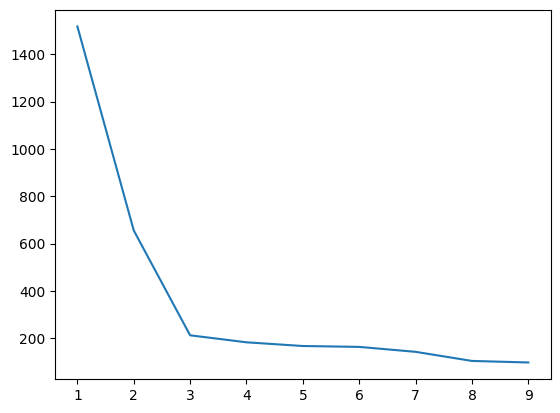

In [6]:
plt.plot(range(1, 10), costs)

From the elbow plot, we can see that k = 3 is the best number of clusters to select

### Step 4: Fit our model with the number of clusters we found is best

In [ ]:
# Example usage
best_cost = float('inf')
best_model = None

for _ in range(100):
    model = KMeans(k = 3)
    model.fit(X)
    cost = model.compute_cost()
    
    if cost < best_cost:
        best_cost = cost
        best_model = model

labels = model.fit(X)
print(f"The best cost is {best_cost}")
print(labels)
    

### Step 6: Visualize clusters

In [ ]:
# Points grouped by cluster
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis')